In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cerenakmese/plantvillage-dataset-in-yolo-format")

print("Path to dataset files:", path)

100%|██████████| 848M/848M [00:05<00:00, 156MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/cerenakmese/plantvillage-dataset-in-yolo-format/versions/1


In [ ]:
!mkdir -p "/content/drive/MyDrive/Datasets/PlantVillage"

In [ ]:
DATASET = "/root/.cache/kagglehub/datasets/cerenakmese/plantvillage-dataset-in-yolo-format/versions/1/yolo_dataset/images/train"
!ls "$DATASET"

Streaming output truncated to the last 5000 lines.
'e8d9d545-23b5-494b-a6ad-f7fe9f3261ff___UF.GRC_YLCV_Lab 09440.JPG'
'e8d9d6fa-568e-4834-a246-d34e1478c77c___FREC_Pwd.M 4884.JPG'
'e8db5472-3858-478a-b1ae-9198329a49a5___RS_Early.B 7528.JPG'
'e8db7386-db51-4952-ba59-4b7bc44b1520___YLCV_NREC 2688.JPG'
'e8dca555-432c-4952-8146-4976ebacd4a5___CREC_HLB 4076.JPG'
'e8df4f2d-fbe1-46f5-bef2-ae5393a46cc9___UF.Citrus_HLB_Lab 1176.JPG'
'e8e03ae2-a11f-4af1-879b-66d71af9ba13___NREC_B.Spot 1857.JPG'
'e8e11355-c9a6-43d7-84f2-046a1068a561___RS_HL 4423.JPG'
'e8e4c7fa-6c75-470a-888a-0763cade48bc___Crnl_L.Mold 7099.JPG'
'e8e7edd6-4791-41f4-a110-41af6fb1e124___GCREC_Bact.Sp 3651.JPG'
'e8eacb74-00fe-4e44-beec-f29c4bb58c58___Com.G_SpM_FL 8479.JPG'
'e8ef5313-e40d-4e48-8697-8f07df4475b0___YLCV_GCREC 5219.JPG'
'e8efa815-c8c2-4b9d-8f5d-77a9557eff85___RS_HL 4544.JPG'
'e8f01d04-432d-4894-990b-df471a782651___RS_HL 6297.JPG'
'e8f1f392-e244-46a0-8852-8fbe2e944fae___YLCV_GCREC 5386.JPG'
'e8f5c962-6f40-443e-9913-5a43b5f

In [ ]:
!rm -r /content/PlantVillage_Classification

In [ ]:
import os
import shutil

yolo_root = "/root/.cache/kagglehub/datasets/cerenakmese/plantvillage-dataset-in-yolo-format/versions/1/yolo_dataset"

images_root = os.path.join(yolo_root, "images")
labels_root = os.path.join(yolo_root, "labels")

output_root = "/content/PlantVillage_Classification"

splits = ["train", "val", "test"]

def convert_split(split):
    print(f"\nProcessing split: {split}")

    img_dir = os.path.join(images_root, split)
    lbl_dir = os.path.join(labels_root, split)

    for lbl in os.listdir(lbl_dir):
        if not lbl.endswith(".txt"):
            continue

        lbl_path = os.path.join(lbl_dir, lbl)
        img_name = lbl.replace(".txt", ".JPG")

        # read class id
        with open(lbl_path, "r") as f:
            first = f.readline().strip()
            if first == "":
                continue
        cls_id = first.split()[0]

        # class folder
        cls_dir = os.path.join(output_root, split, cls_id)
        os.makedirs(cls_dir, exist_ok=True)

        # find image
        img_path = os.path.join(img_dir, img_name)
        if not os.path.exists(img_path):
            for ext in ["jpg", "jpeg", "png"]:
                test_path = os.path.join(img_dir, lbl.replace(".txt", f".{ext}"))
                if os.path.exists(test_path):
                    img_path = test_path
                    break

        if os.path.exists(img_path):
            shutil.copy(img_path, cls_dir)

for split in splits:
    convert_split(split)

print("DONE")


Processing split: train

Processing split: val

Processing split: test
DONE


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/PlantVillage_Classification/train"

gen = ImageDataGenerator(rescale=1/255)
data = gen.flow_from_directory(train_dir)

print("Detected classes:", data.num_classes)

Found 43983 images belonging to 38 classes.
Detected classes: 38


Found 43983 images belonging to 38 classes.
Found 4887 images belonging to 38 classes.
Detected classes: 38


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,665,574 (90.28 MB)

 Trainable params: 77,862 (304.15 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 607s 433ms/step - accuracy: 0.0812 - loss: 3.5690 - val_accuracy: 0.1645 - val_loss: 3.2601
Epoch 2/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 577s 420ms/step - accuracy: 0.1189 - loss: 3.3434 - val_accuracy: 0.1883 - val_loss: 3.1873
Epoch 3/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 573s 417ms/step - accuracy: 0.1453 - loss: 3.2595 - val_accuracy: 0.2136 - val_loss: 3.1364
Epoch 4/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 575s 418ms/step - accuracy: 0.1677 - loss: 3.2064 - val_accuracy: 0.2310 - val_loss: 3.0833
Epoch 5/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 571s 415ms/step - accuracy: 0.1838 - loss: 3.1650 - val_accuracy: 0.2316 - val_loss: 3.0417
Epoch 6/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 624s 417ms/step - accuracy: 0.1948 - loss: 3.1339 - val_accuracy: 0.2421 - val_loss: 3.0099
Epoch 7/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 580s 422ms/step - accuracy: 0.2027 - loss: 3.1041 - val_accuracy: 0.2408 - val_loss: 2.9781
Epoch 8/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 580s 422ms/step - ac

Model saved.


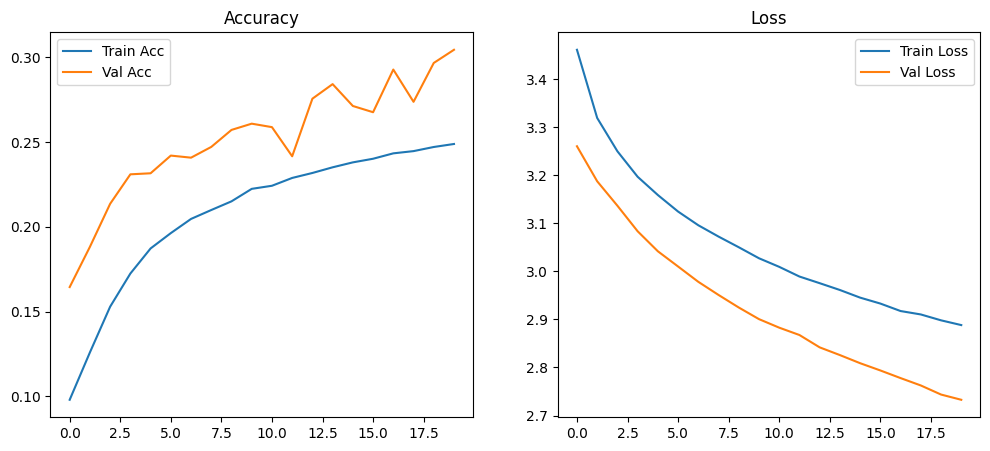

In [ ]:
# ---------------------------------------------------------
# ResNet50 Training Script
# ---------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

train_dir = "/content/PlantVillage_Classification/train"
val_dir   = "/content/PlantVillage_Classification/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# -------------------------------
# Data Augmentation
# -------------------------------
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

val_data = val_gen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

NUM_CLASSES = train_data.num_classes
print("Detected classes:", NUM_CLASSES)

# -------------------------------
# Load ResNet50
# -------------------------------
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
preds = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)

model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# -------------------------------
# Train
# -------------------------------
history = model.fit(train_data, validation_data=val_data, epochs=20)

# -------------------------------
# Save
# -------------------------------
model_save_path = "/content/drive/MyDrive/PlantDisease_Models/ResNet50_PlantVillage.h5"
model.save(model_save_path)
print(f"Model saved successfully at: {model_save_path}")

# -------------------------------
# Plot Accuracy/Loss
# -------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()

Found 43983 images belonging to 38 classes.
Found 4887 images belonging to 38 classes.

Detected Classes: 38
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,665,574 (90.28 MB)

 Trainable params: 77,862 (304.15 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 602s 427ms/step - accuracy: 0.0840 - loss: 3.6446 - val_accuracy: 0.1539 - val_loss: 3.2640
Epoch 2/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 566s 412ms/step - accuracy: 0.1163 - loss: 3.3636 - val_accuracy: 0.1680 - val_loss: 3.2002
Epoch 3/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 566s 412ms/step - accuracy: 0.1353 - loss: 3.2854 - val_accuracy: 0.2216 - val_loss: 3.1421
Epoch 4/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 565s 411ms/step - accuracy: 0.1620 - loss: 3.2297 - val_accuracy: 0.2138 - val_loss: 3.1013
Epoch 5/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 560s 407ms/step - accuracy: 0.1758 - loss: 3.1838 - val_accuracy: 0.2210 - val_loss: 3.0672
Epoch 6/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 565s 411ms/step - accuracy: 0.1859 - loss: 3.1593 - val_accuracy: 0.2202 - val_loss: 3.0298
Epoch 7/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 561s 408ms/step - accuracy: 0.1978 - loss: 3.1185 - val_accuracy: 0.2484 - val_loss: 3.0021
Epoch 8/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 560s 407ms/step - ac


Model successfully saved to: /content/drive/MyDrive/PlantVillage_Models/ResNet50_PlantVillage.h5


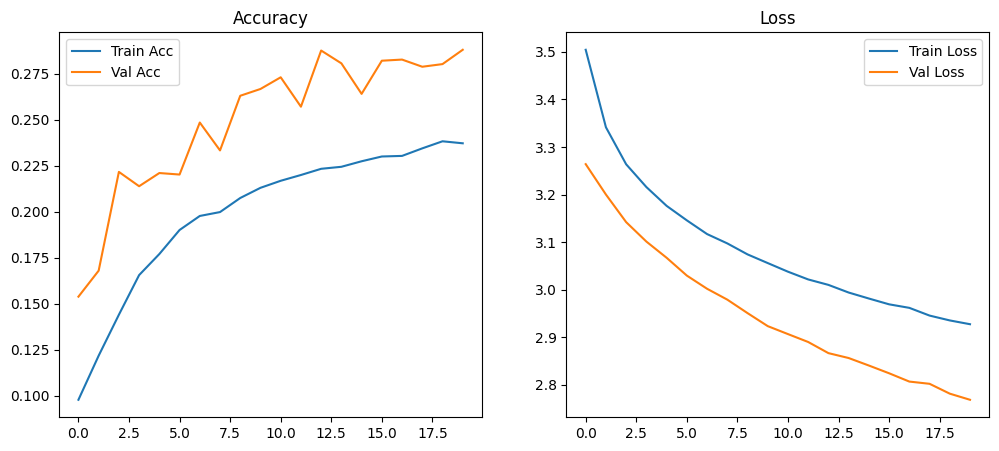

In [ ]:
# ---------------------------------------------------------
# ResNet50 Training Script - Final Working Version
# ---------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

# Google Drive save path
SAVE_PATH = "/content/drive/MyDrive/PlantVillage_Models"
os.makedirs(SAVE_PATH, exist_ok=True)

# Dataset
train_dir = "/content/PlantVillage_Classification/train"
val_dir   = "/content/PlantVillage_Classification/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

val_data = val_gen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical"
)

NUM_CLASSES = train_data.num_classes
print("\nDetected Classes:", NUM_CLASSES)

# Load ResNet50
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False   # Freeze pretrained layers

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
preds = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=preds)
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# Save Model to Google Drive
model_path = f"{SAVE_PATH}/ResNet50_PlantVillage.h5"
model.save(model_path)
print("\nModel successfully saved to:", model_path)

# Plot Accuracy & Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [2]:
!find /content/drive/MyDrive -name "*.h5"


find: ‘/content/drive/MyDrive/Datasets/PlantVillage/1/temp_generated_labels’: Input/output error
find: ‘/content/drive/MyDrive/Datasets/PlantVillage/1/yolo_dataset/images/train’: Input/output error
/content/drive/MyDrive/PlantVillage_Models/ResNet50_PlantVillage.h5


✔ Model Loaded Successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Predicted: Grape___Black_rot (0.20)


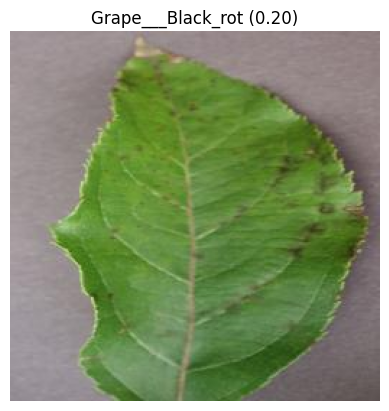

In [6]:
# ---------------------------------------------
# Load and Test ResNet50 Plant Disease Model
# ---------------------------------------------

import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model from Google Drive
MODEL_PATH = "/content/drive/MyDrive/PlantVillage_Models/ResNet50_PlantVillage.h5"
model = tf.keras.models.load_model(MODEL_PATH)
print("✔ Model Loaded Successfully")

# Class label names (Replace this with your actual labels order)
class_names = [
    'Apple___Black_rot', 'Apple___healthy', 'Apple___rust',
    'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot',
    'Corn___Common_rust', 'Corn___Northern_Leaf_Blight',
    'Grape___Black_rot', 'Grape___Leaf_blight',
    'Peach___healthy', 'Pepper___Bacterial_spot',
    'Potato___Early_blight', 'Potato___Late_blight',
    'Soybean___healthy', 'Strawberry___Leaf_scorch',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight',
    'Tomato___Late_blight', 'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites',
    'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# Path to test image
TEST_IMAGE_PATH = "/content/image (1).JPG"  # <-- Change this

# Preprocess image
img = image.load_img(TEST_IMAGE_PATH, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Prediction
pred = model.predict(img_array)
class_index = np.argmax(pred)
confidence = np.max(pred)

print(f"\nPredicted: {class_names[class_index]} ({confidence:.2f})")

# Display input image with result
plt.imshow(image.load_img(TEST_IMAGE_PATH))
plt.title(f"{class_names[class_index]} ({confidence:.2f})")
plt.axis("off")
plt.show()


✔ Model Loaded Successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Predicted: Tomato___Late_blight (0.10)


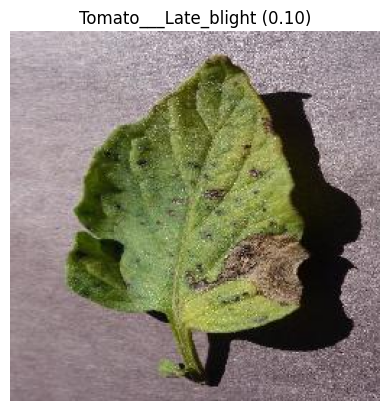

In [14]:
# ---------------------------------------------
# Load and Test ResNet50 Plant Disease Model
# ---------------------------------------------

import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model from Google Drive
MODEL_PATH = "/content/drive/MyDrive/PlantVillage_Models/ResNet50_PlantVillage.h5"
model = tf.keras.models.load_model(MODEL_PATH)
print("✔ Model Loaded Successfully")

# Class label names (Replace this with your actual labels order)
class_names = [
    'Apple___Black_rot', 'Apple___healthy', 'Apple___rust',
    'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot',
    'Corn___Common_rust', 'Corn___Northern_Leaf_Blight',
    'Grape___Black_rot', 'Grape___Leaf_blight',
    'Peach___healthy', 'Pepper___Bacterial_spot',
    'Potato___Early_blight', 'Potato___Late_blight',
    'Soybean___healthy', 'Strawberry___Leaf_scorch',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight',
    'Tomato___Late_blight', 'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites',
    'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# Path to test image
TEST_IMAGE_PATH = "/content/image (2).JPG"  # <-- Change this

# Preprocess image
img = image.load_img(TEST_IMAGE_PATH, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Prediction
pred = model.predict(img_array)
class_index = np.argmax(pred)
confidence = np.max(pred)

print(f"\nPredicted: {class_names[class_index]} ({confidence:.2f})")

# Display input image with result
plt.imshow(image.load_img(TEST_IMAGE_PATH))
plt.title(f"{class_names[class_index]} ({confidence:.2f})")
plt.axis("off")
plt.show()
